# **RANDOM FOREST**

Dopo aver trovato il miglior modello, vediamo come se la cava in cross-validation al variare del numero di fold.

## Preparazione dei dati

---

In [ ]:
import numpy as np
# Segnale su cui effettuare Train e Validation
g_0_b = np.loadtxt('data/g_0_signal_b.txt')
g_1_b = np.loadtxt('data/g_1_signal_b.txt')
# Segnale su cui effettuare Test Esterno
g_0_a = np.loadtxt('data/g_0_signal_a.txt')
g_1_a = np.loadtxt('data/g_1_signal_a.txt')

Concatenazione gruppi e vettore dei label:

In [ ]:
N0, N1 = g_0_b.shape[0], g_1_b.shape[0]
# concateno g_0 e g_1
signal_b = np.vstack((g_0_b, g_1_b))
signal_a = np.vstack((g_0_a, g_1_a))

# vettore delle risposte
labels = np.concatenate((np.zeros(N0), np.ones(N1))) # uguale per A e B

## Variando il numero di fold

---

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier as RFC

Stavolta niente `GridSearch`, facciamo due cicli `for` manuali su `k` e `n_estimators`.

In [ ]:
# dizionari per i risultati
acc_dict, std_dict = {}, {}

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score

k_list = np.arange(2, 23, 1)
N_ESTIMATOR_OPTIONS = [50, 75, 100, 125, 150, 175, 200]

for k in k_list:
    acc_dict[k] = []
    std_dict[k] = []
    n_repeats = 20 if k < 15 else 10 
    rkf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
    print(f"- k={k}")
    
    for N_e in N_ESTIMATOR_OPTIONS:

        pipe = Pipeline([
            ("scaling", StandardScaler()),       
            #("reduce_dim", PCA(n_components=5, random_state=42)),
            ("classify", RFC(
                n_estimators=N_e, 
                bootstrap=True, 
                criterion='gini',
                max_features = 'sqrt',
                min_samples_leaf = 1,
                max_depth=4,
                random_state=42)) 
        ])
        
        acc = cross_val_score(
            pipe, 
            X=signal_b, 
            y=labels, 
            cv=rkf,
            n_jobs=-1
        )
        
        m, s = acc.mean(), acc.std()
        
        print(f"   • N_e = {N_e}, acc = {m:.3f} ± {s:.3f}", flush=True)
        
        acc_dict[k].append(m)
        std_dict[k].append(s)

- k=2


   • N_e = 50, acc = 0.649 ± 0.080
   • N_e = 75, acc = 0.668 ± 0.080
   • N_e = 100, acc = 0.672 ± 0.064
   • N_e = 125, acc = 0.667 ± 0.069
   • N_e = 150, acc = 0.681 ± 0.081
   • N_e = 175, acc = 0.678 ± 0.072
   • N_e = 200, acc = 0.678 ± 0.076
- k=3
   • N_e = 50, acc = 0.688 ± 0.122
   • N_e = 75, acc = 0.704 ± 0.111
   • N_e = 100, acc = 0.692 ± 0.103
   • N_e = 125, acc = 0.701 ± 0.110
   • N_e = 150, acc = 0.709 ± 0.120
   • N_e = 175, acc = 0.709 ± 0.116
   • N_e = 200, acc = 0.710 ± 0.115
- k=4
   • N_e = 50, acc = 0.709 ± 0.130
   • N_e = 75, acc = 0.715 ± 0.128
   • N_e = 100, acc = 0.716 ± 0.126
   • N_e = 125, acc = 0.713 ± 0.126
   • N_e = 150, acc = 0.730 ± 0.133
   • N_e = 175, acc = 0.731 ± 0.129
   • N_e = 200, acc = 0.731 ± 0.126
- k=5
   • N_e = 50, acc = 0.703 ± 0.153
   • N_e = 75, acc = 0.715 ± 0.151
   • N_e = 100, acc = 0.711 ± 0.152
   • N_e = 125, acc = 0.703 ± 0.151
   • N_e = 150, acc = 0.716 ± 0.142
   • N_e = 175, acc = 0.715 ± 0.151
   • N_e = 200, ac

In [ ]:
# Creiamo il DataFrame: le chiavi del dizionario (k) diventano le colonne
# L'indice (le righe) sarà la lista degli stimatori che hai usato
df_acc = pd.DataFrame(acc_dict, index=N_ESTIMATOR_OPTIONS)

# Rinominiamo gli assi per chiarezza
df_acc.index.name = "N Estimators"
df_acc.columns.name = "k Folds"

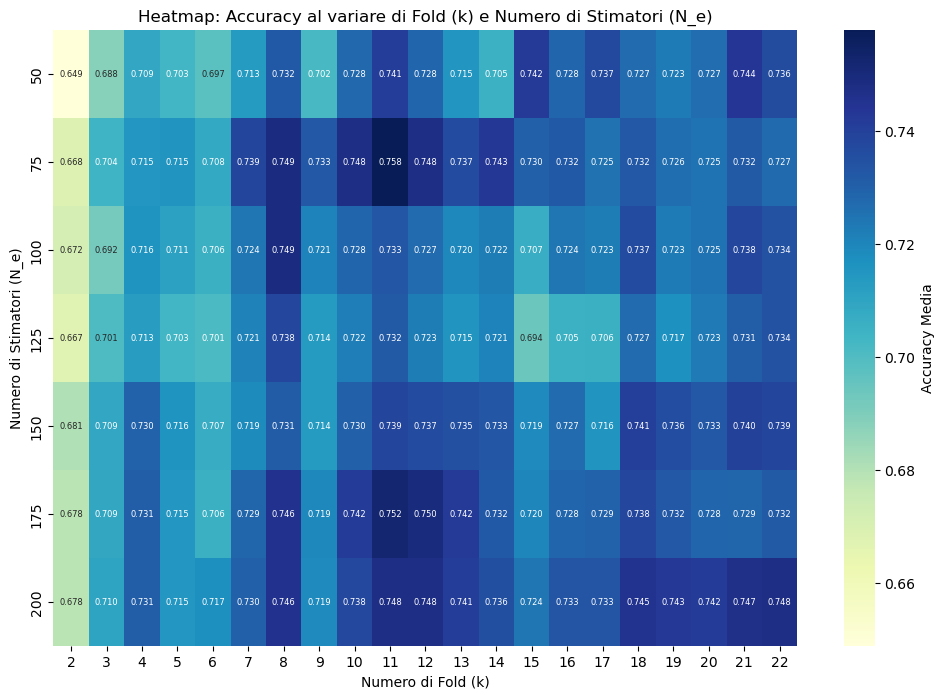

In [ ]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df_acc, 
    annot=True,      # Scrive il valore dell'accuracy dentro ogni cella
    fmt=".3f",       # Formato a 3 decimali
    cmap="YlGnBu",   # Colormap dal giallo (basso) al blu (alto)
    cbar_kws={'label': 'Accuracy Media'},
    annot_kws={"size": 6}
)

plt.title("Heatmap: Accuracy al variare di Fold (k) e Numero di Stimatori (N_e)")
plt.xlabel("Numero di Fold (k)")
plt.ylabel("Numero di Stimatori (N_e)")
plt.show()